In [16]:
# getting in datasets 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df1 = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\Bank_Churn.csv")
df2 = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\CustomerInfo.csv")
# Merging datasets
df = pd.merge(df1,df2,on='CustomerId',how='left')

# Data cleaning 
# Converting data types
df['Bank DOJ'] = pd.to_datetime(df['Bank DOJ'], dayfirst=True, errors='coerce')
df['GenderID'].value_counts()
df['Gender'] = df['GenderID'].map({1:'Male',2:'Female'})
df['GeographyLocation'] = df['GeographyID'].map({1:'France',2:'Spain',3:'Germany'})
df['CreditCard'] = df['HasCrCard'].map({1:'Credit card holder',0:'Non Credit card holder'})
df['ActivityStatus'] = df['IsActiveMember'].map({1:'Active member',0:'Non Active member'})
df ['Churn'] = df['Exited'].map({1:'Exit',0:'Retained'})
df.drop(['RowNumber','GeographyID','GenderID','HasCrCard','IsActiveMember','Exited'],axis=1,inplace=True)
cat_cols = ['Gender','GeographyLocation','CreditCard','ActivityStatus','Churn']
for col in cat_cols:
    df[col] = df[col].astype('category')
# checking missing values
df.isnull().sum()
# Checking duplicates 
df['CustomerId'].duplicated().sum()
# Outliers Detection
num_cols = df.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3-q1
    lower = q1-(1.5*IQR)
    upper = q3+(1.5*IQR)
    outliers = df[col][(df[col]<lower) | (df[col]>upper)]
    print(col,"-",len(outliers))
    


CustomerId - 0
CreditScore - 15
Age - 359
Tenure - 0
Balance - 0
NumOfProducts - 60
EstimatedSalary - 0


In [ ]:
# Feature Engineering 
def categorize_credit(score):
    if 300 <= score <= 579:
        return 'Poor'
    elif 580 <= score <= 669:
        return 'Fair'
    elif 670 <= score <= 739:
        return 'Good'
    elif 740 <= score <= 799:
        return 'Very Good'
    elif 800 <= score <= 850:
        return 'Excellent'
    else:
        return 'Unknown'
df['CreditScoreCategory'] = df['CreditScore'].apply(categorize_credit)
df['CreditScoreCategory'] = df['CreditScoreCategory'].astype('category')
df['CreditScoreCategory'] = pd.Categorical(df['CreditScoreCategory'],categories=['Poor','Fair','Good','Very Good','Excellent'],ordered=True)
df['CreditScoreCategory'].value_counts().sort_index()

In [3]:
# EDA
# Categorical Analysis
# Percentage of churned customers by credit category
churn_credit = df[df['Churn'] == 'Exit']['CreditScoreCategory'].value_counts(normalize=True)*100
print(churn_credit)

CreditScoreCategory
Fair         33.627884
Poor         25.527737
Good         22.189494
Very Good    12.371134
Excellent     6.283751
Name: proportion, dtype: float64


In [4]:
# Percentage of churned customers by CardHolders
churn_card = df[df['Churn'] == 'Exit']['CreditCard'].value_counts(normalize=True)*100
print(churn_card)

CreditCard
Credit card holder        69.906726
Non Credit card holder    30.093274
Name: proportion, dtype: float64


In [5]:
# Percentage of churned customers by Location
churn_location = df[df['Churn'] == 'Exit']['GeographyLocation'].value_counts(normalize=True)*100
print(churn_location)

GeographyLocation
Germany    39.960727
France     39.764359
Spain      20.274914
Name: proportion, dtype: float64


In [6]:
# Monthly churn analysis
df['Month'] = df['Bank DOJ'].dt.month_name()
churn_monthly = df[df['Churn'] == 'Exit']['Month'].value_counts(normalize=True)*100
print(churn_monthly) 

Month
November     15.071183
December     13.892980
September    13.794796
October       8.345606
June          7.658321
May           7.167403
March         6.725577
April         6.529210
August        6.529210
July          6.381934
January       5.056456
February      2.847324
Name: proportion, dtype: float64


In [7]:
# Yearly Churn Analysis
df['Year'] = df['Bank DOJ'].dt.year
churn_year = df[df['Churn'] == 'Exit']['Year'].value_counts(normalize=True)*100
print(churn_year) 

Year
2019    32.302405
2018    25.724104
2017    23.514973
2016    18.458517
Name: proportion, dtype: float64


In [8]:
# Percentage of churned customers by Activity
churn_active = df[df['Churn'] == 'Exit']['ActivityStatus'].value_counts(normalize=True)*100
print(churn_active)

ActivityStatus
Non Active member    63.917526
Active member        36.082474
Name: proportion, dtype: float64


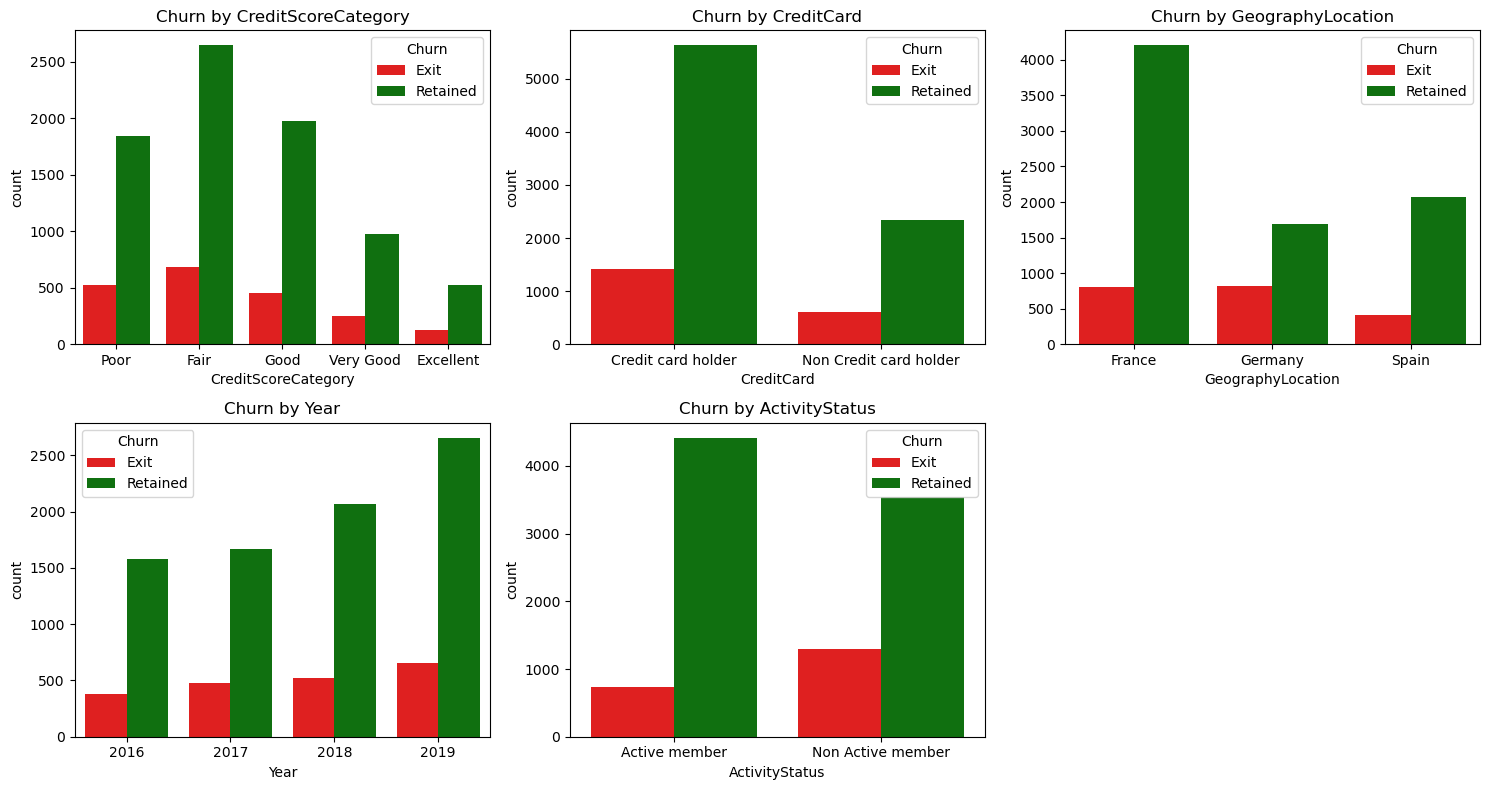

In [11]:

# Visualizing Churn
pltt = {'Exit':'red','Retained':'green'}
cat_cols = ['CreditScoreCategory','CreditCard','GeographyLocation','Year','ActivityStatus']
plt.figure(figsize=(15,8))
for i,col in enumerate(cat_cols):
    plt.subplot(2,3,i+1)
    sns.countplot(data=df,x=col,hue='Churn',palette=pltt)
    plt.title(f'Churn by {col}')
plt.tight_layout()
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_7016\3919265906.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn_num'] = df['Churn'].replace({'Retained':0,'Exit':1})


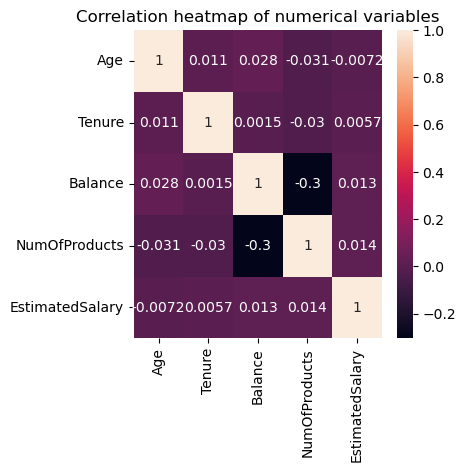

In [13]:
# Numerical Analysis
df['Churn'] = df['Churn'].str.strip()
df['Churn_num'] = df['Churn'].replace({'Retained':0,'Exit':1})
num_cols = ['Age','Tenure','Balance','NumOfProducts','EstimatedSalary']
plt.figure(figsize=(4,4))
sns.heatmap(df[num_cols].corr(),annot=True)
plt.title('Correlation heatmap of numerical variables')
plt.show()


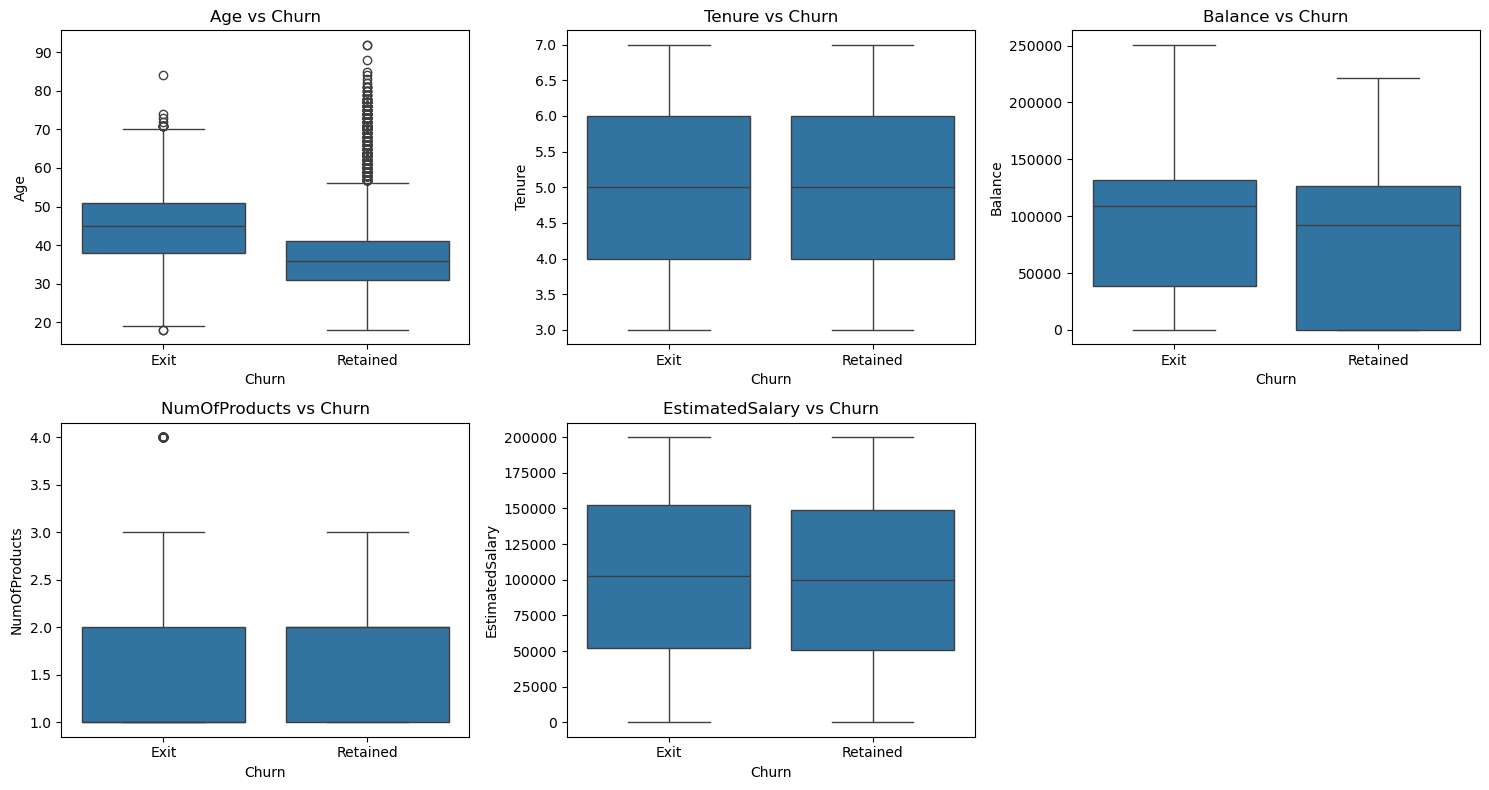

In [12]:
num_cols = ['Age','Tenure','Balance','NumOfProducts','EstimatedSalary']
plt.figure(figsize=(15,8))
for i,col in enumerate(num_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(x='Churn',y=col,data=df)
    plt.title(f'{col} vs Churn')
plt.tight_layout()
plt.show()
     
   